# Подготовка окружения

In [1]:
!pip install "dask[complete]" graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00


In [2]:
import sys
import os
import pandas as pd
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:38365
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40109'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33855'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38881 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38881
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:47886
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39599 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:39599
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38365,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39599,Total threads: 2
Dashboard: http://127.0.0.1:37851/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40109,


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/etl

/content/drive/MyDrive/etl


In [22]:
  ls

austinHousingData.csv  cleaned_data.parquet/  homeImages/


# Шаг 1. Extract (Извлечение данных)

In [6]:
df = dd.read_csv('austinHousingData.csv',  dtype={'zipcode': 'object', 'latest_saledate': 'object', 'homeImage': 'object'})
df

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,hasGarage,hasHeating,hasSpa,hasView,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,latest_saledate,latest_salemonth,latest_saleyear,latestPriceSource,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,numOfPatioAndPorchFeatures,numOfSecurityFeatures,numOfWaterfrontFeatures,numOfWindowFeatures,numOfCommunityFeatures,lotSizeSqFt,livingAreaSqFt,numOfPrimarySchools,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,float64,float64,float64,int64,bool,bool,bool,bool,bool,bool,string,int64,int64,float64,int64,string,int64,int64,string,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,int64,int64,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


# Шаг 2. Transform (Трансформация и очистка данных)

In [7]:
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
MedianStudentsPerTeacher    int64
zpid                          ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(a149ffa)))).sum()

In [8]:
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)
missing_count

Dask Series Structure:
npartitions=1
MedianStudentsPerTeacher    float64
zpid                            ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(a149ffa)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(a149ffa))).size() * 100

In [9]:
with ProgressBar():
  missing_count_percent = missing_count.compute()
missing_count_percent

,0
zpid,0.000000
city,0.000000
streetAddress,0.000000
zipcode,0.000000
description,0.013183
latitude,0.000000
longitude,0.000000
propertyTaxRate,0.000000
garageSpaces,0.000000
hasAssociation,0.000000


Видим, что в датасете отсутвуют поля с пропусками

Проверим поле zpid на уникальность значений

In [ ]:
unique_zpids = df['zpid'].nunique()
zpid_freq = df['zpid'].value_counts()

duplicate_rows = (zpid_freq - 1).sum()

In [ ]:
with ProgressBar():
    n_unique = unique_zpids.compute()
    n_duplicate_rows = duplicate_rows.compute()

print(f"Уникальных zpid: {n_unique}")
print(f"Дублированных строк: {n_duplicate_rows}")

Уникальных zpid: 15171
Дублированных строк: 0


Проверим, для всех ли записей датасета есть соответствующая фотография

In [ ]:
images_folder = 'homeImages'

# Создадим множество из имени файлов в папке с фото
available_images = set(os.listdir(images_folder))
print(f"Найдено фото в папке: {len(available_images)}")

Найдено фото в папке: 15171


In [ ]:
# Функция для проверки
def has_photo(image_name):
    if pd.isna(image_name) or image_name == '':
        return False
    return image_name in available_images

# Создаем план вычислений
df['photo_exists'] = df['homeImage'].map(has_photo, meta=('photo_exists', 'bool'))
houses_with_photo = df['photo_exists'].sum()
total_houses = df.index.size
percent_with_photo = (houses_with_photo / total_houses) * 100

In [ ]:
# Запускаем реальные вычисления
with ProgressBar():
    result = percent_with_photo.compute()

print(f"Домов с фото: {result:.2f}%")
print(f"Домов без фото: {houses_without_photo:,} ({houses_without_photo/total_houses*100:.2f}%)")

Домов с фото: 100.00%
Домов без фото: 0 (0.00%)


Также видим, что дома без фото в нашем датасете отсутствуют. В таком случае просто уберем столбцы, которые нам не нужны для анализа

In [ ]:
cols_to_drop = ['numOfParkingFeatures', 'numOfWindowFeatures',
                'numOfPatioAndPorchFeatures', 'numOfSecurityFeatures',
                'numOfWaterfrontFeatures', 'numOfAccessibilityFeatures',
                'numOfPrimarySchools', 'numOfElementarySchools',
                'numOfMiddleSchools', 'numOfHighSchools',
                'avgSchoolDistance', 'avgSchoolSize', 'MedianStudentsPerTeacher']

df_cleaned = df.drop(columns=cols_to_drop)

# Шаг 3. Load (Сохранение результатов пайплайна)

In [ ]:
df_cleaned.to_parquet('cleaned_data.parquet')

# Шаг 4. Визуализация направленных ациклических графов (DAG)

Сначала создадим простой граф, визуализирующий процесс подсчета стоимости всего жилого фонда в датасете

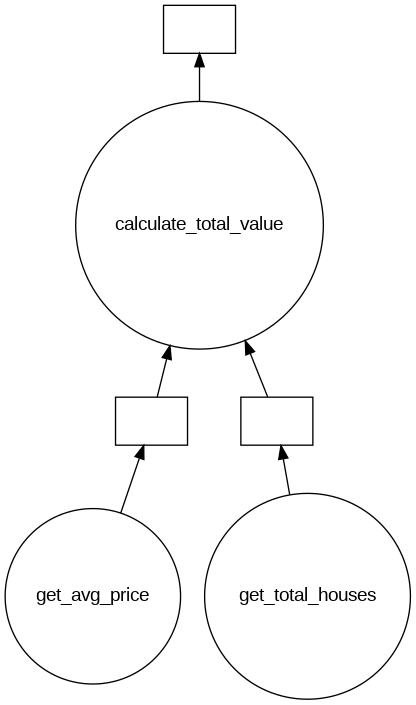

In [ ]:
# Подсчет общего количества домов
def get_total_houses():
    return len(df)

# Подсчет средней цены
def get_avg_price():
    return df['latestPrice'].mean().compute()

# Вычисление стоимости всего жилого фонда
def calculate_total_value(total, avg):
    return total * avg

# Создание отложенных объектов
x = delayed(get_total_houses)()
y = delayed(get_avg_price)()
z = delayed(calculate_total_value)(x, y)

# Визуализация графа
z.visualize(filename='easy_dask.png')

from IPython.display import Image
display(Image('easy_dask.png'))

# Запуск вычислений и получение результата
result = z.compute()

Теперь создадим сложный граф, который отражает процесс проведения расчетов

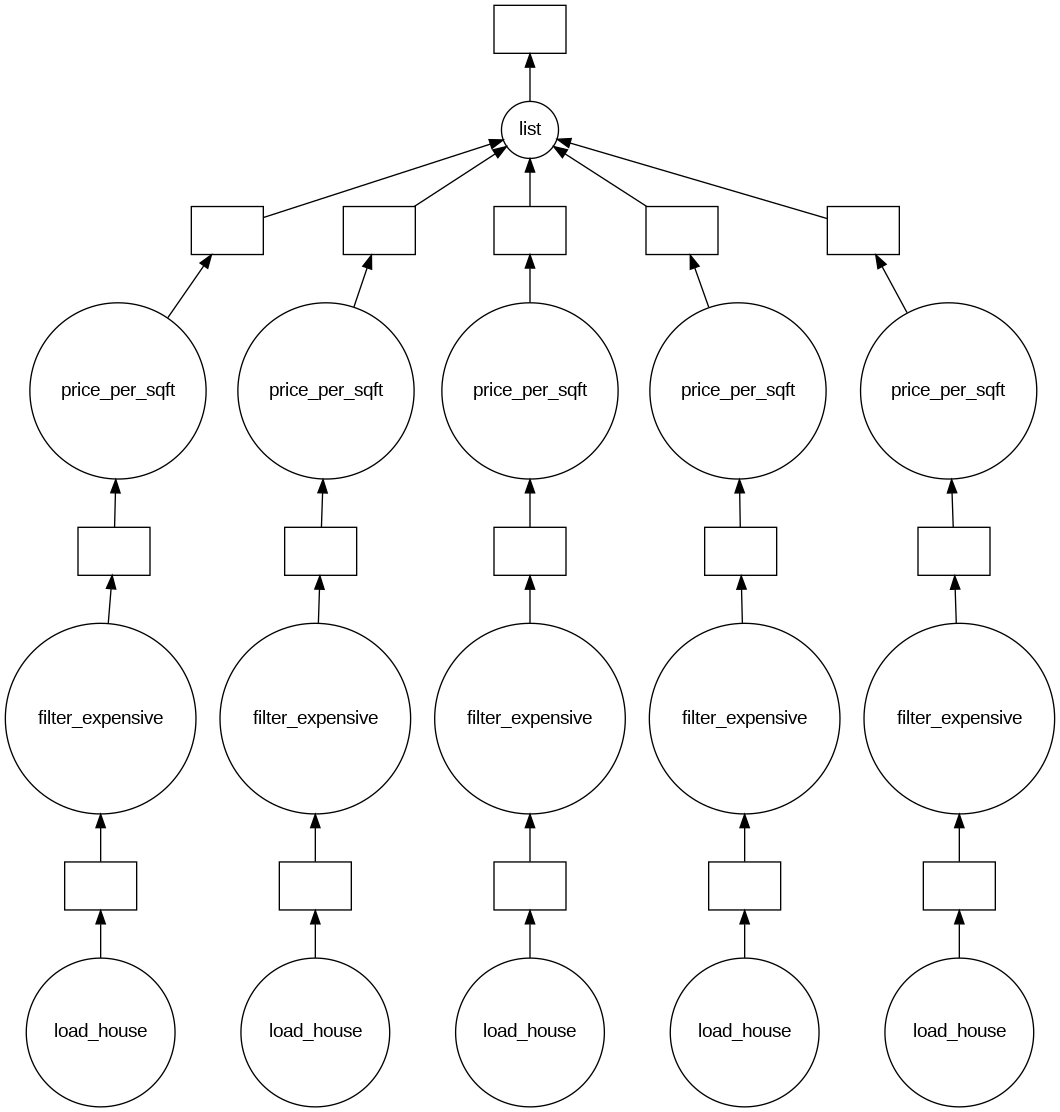

In [ ]:
# Cписок zpid домов
houses = [101, 102, 103, 104, 105]

# Слой 1: Загружаем каждый дом
def load_house(h):
    return f"дом_{h}"

layer1 = [delayed(load_house)(h) for h in houses]

# Слой 2: Проверяем цену
def filter_expensive(house):
    if house['price'] > 500000:
        return house
    return None

layer2 = [delayed(filter_expensive)(h) for h in layer1]

# Слой 3: Считаем площадь
def price_per_sqft(house):
    if house is None:
        return None
    house['price_per_sqft'] = round(house['price'] / house['sqft'], 2)
    return house

layer3 = [delayed(price_per_sqft)(h) for h in layer2]

total = delayed(list)(layer3)

# Визуализация
total.visualize(filename='difficult_dask.png')
display(Image('difficult_dask.png'))

# Анализ датасета

Проведем анализ датасета и создадим дашборд, отражающий ключевые метрики

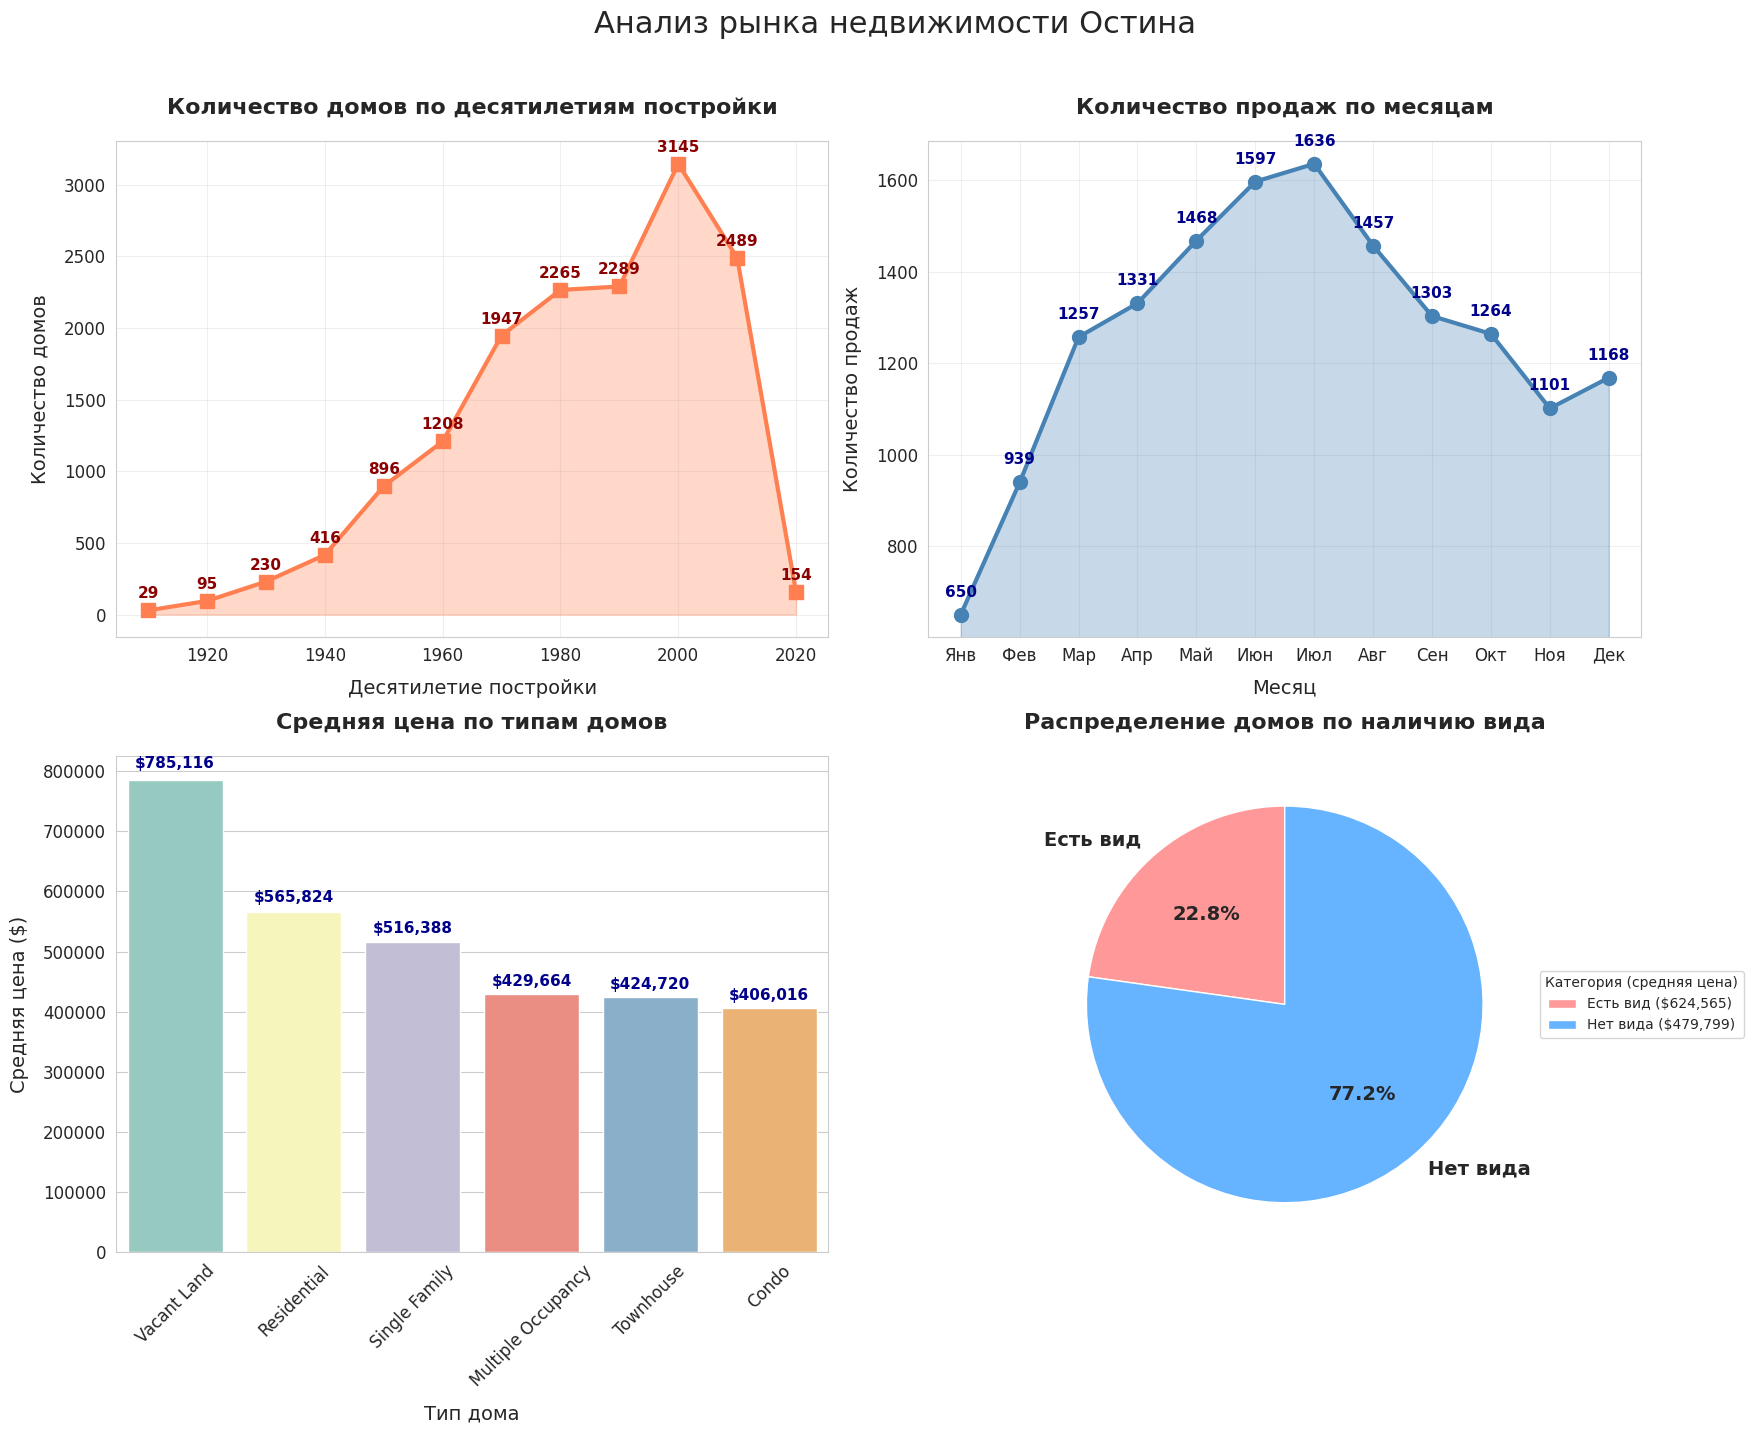

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


# Подготовка данных
# Создаем копию необходимых колонок в pandas для визуализации
df_pd = df[['yearBuilt', 'latest_salemonth', 'homeType', 'latestPrice', 'hasView']].compute()

# Предобработка данных для четвертого графика
df_pd['view_category'] = df_pd['hasView'].astype(str).map({
    'True': 'Есть вид',
    'False': 'Нет вида'
})
df_pd['view_category'] = df_pd['view_category'].fillna('Нет данных')


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Анализ рынка недвижимости Остина', fontsize=22, y=1.02)

ax = axes.flatten()

# График 1
ax1 = ax[0]

df_pd['build_decade'] = (df_pd['yearBuilt'] // 10) * 10
decade_counts = df_pd.groupby('build_decade').size().reset_index()
decade_counts.columns = ['build_decade', 'count']
decade_counts = decade_counts[decade_counts['build_decade'] > 1900].sort_values('build_decade')

if len(decade_counts) > 0:
    ax1.fill_between(decade_counts['build_decade'], decade_counts['count'],
                     alpha=0.3, color='coral')
    ax1.plot(decade_counts['build_decade'], decade_counts['count'],
             marker='s', linewidth=3, markersize=10, color='coral')

    for i, row in decade_counts.iterrows():
        ax1.text(row['build_decade'], row['count'] + decade_counts['count'].max()*0.02,
                 f'{int(row["count"])}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='darkred')
else:
    ax1.text(0.5, 0.5, 'Нет данных по годам постройки', ha='center', va='center', fontsize=14)

ax1.set_title('Количество домов по десятилетиям постройки', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Десятилетие постройки', fontsize=14, labelpad=10)
ax1.set_ylabel('Количество домов', fontsize=14, labelpad=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)

# График 2
ax2 = ax[1]

df_pd['sale_month'] = pd.to_numeric(df_pd['latest_salemonth'], errors='coerce')
monthly_sales = df_pd['sale_month'].value_counts().sort_index().reset_index()
monthly_sales.columns = ['month', 'count']
monthly_sales = monthly_sales.dropna()

if len(monthly_sales) > 0:
    month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                   'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    monthly_sales['month_name'] = monthly_sales['month'].astype(int).map(lambda x: month_names[x-1] if 1 <= x <= 12 else x)

    ax2.fill_between(range(len(monthly_sales)), monthly_sales['count'],
                     alpha=0.3, color='steelblue')
    ax2.plot(monthly_sales['month_name'], monthly_sales['count'],
             marker='o', linewidth=3, markersize=10, color='steelblue')

    for i, row in monthly_sales.iterrows():
        ax2.text(i, row['count'] + monthly_sales['count'].max()*0.02,
                 f'{int(row["count"])}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='darkblue')
else:
    ax2.text(0.5, 0.5, 'Нет данных по месяцам продаж', ha='center', va='center', fontsize=14)

ax2.set_title('Количество продаж по месяцам', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Месяц', fontsize=14, labelpad=10)
ax2.set_ylabel('Количество продаж', fontsize=14, labelpad=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=12)

# График 3
ax3 = ax[2]

top_types = df_pd['homeType'].value_counts().head(6).index
type_avg = df_pd[df_pd['homeType'].isin(top_types)].groupby('homeType')['latestPrice'].mean().sort_values(ascending=False).reset_index()
type_avg.columns = ['homeType', 'latestPrice']

bars3 = sns.barplot(data=type_avg, x='homeType', y='latestPrice', palette='Set3', hue='homeType', legend=False, ax=ax3)
ax3.set_title('Средняя цена по типам домов', fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Тип дома', fontsize=14, labelpad=10)
ax3.set_ylabel('Средняя цена ($)', fontsize=14, labelpad=10)
ax3.tick_params(axis='x', rotation=45, labelsize=12)
ax3.tick_params(axis='y', labelsize=12)

for i, bar in enumerate(bars3.patches):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'${height:,.0f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='darkblue')

# График 4
ax4 = ax[3]

view_filtered = df_pd[df_pd['view_category'].isin(['Нет вида', 'Есть вид'])]

if len(view_filtered) > 0:
    view_stats = view_filtered.groupby('view_category')['latestPrice'].agg(['mean', 'count']).reset_index()

    total = view_stats['count'].sum()
    view_stats['percentage'] = (view_stats['count'] / total * 100).round(1)

    if len(view_stats) == 2:
        colors = ['#ff9999', '#66b3ff']

        wedges, texts, autotexts = ax4.pie(view_stats['count'],
                                           labels=view_stats['view_category'],
                                           colors=colors,
                                           autopct='%1.1f%%',
                                           textprops={'fontsize': 14, 'fontweight': 'bold'},
                                           startangle=90)

        legend_labels = [f"{row['view_category']} (${row['mean']:,.0f})"
                         for _, row in view_stats.iterrows()]
        ax4.legend(wedges, legend_labels, title="Категория (средняя цена)",
                   loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    else:
        ax4.text(0.5, 0.5, 'Недостаточно данных\nдля отображения',
                 ha='center', va='center', fontsize=14, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Нет данных по виду',
             ha='center', va='center', fontsize=14, fontweight='bold')

ax4.set_title('Распределение домов по наличию вида',
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()